# Problem Statement:
## To identify and analyze the key factors (e.g., budget, genre, director, star, score, votes) that significantly influence a movie's gross revenue and critical success.' This would involve exploring relationships between these attributes and the movie's performance metrics.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files


In [ ]:
u=files.upload()

Saving movies.csv to movies.csv


In [ ]:
df=pd.read_csv('/content/movies.csv')
df

,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000.0,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000.0,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000.0,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000.0,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000.0,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000.0,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000.0,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000.0,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000.0,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000.0,39846344.0,Orion Pictures,98.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7663,More to Life,NaN,Drama,2020,"October 23, 2020 (United States)",3.1,18.0,Joseph Ebanks,Joseph Ebanks,Shannon Bond,United States,7000.0,NaN,NaN,90.0
7664,Dream Round,NaN,Comedy,2020,"February 7, 2020 (United States)",4.7,36.0,Dusty Dukatz,Lisa Huston,Michael Saquella,United States,NaN,NaN,Cactus Blue Entertainment,90.0
7665,Saving Mbango,NaN,Drama,2020,"April 27, 2020 (Cameroon)",5.7,29.0,Nkanya Nkwai,Lynno Lovert,Onyama Laura,United States,58750.0,NaN,Embi Productions,NaN
7666,It's Just Us,NaN,Drama,2020,"October 1, 2020 (United States)",NaN,NaN,James Randall,James Randall,Christina Roz,United States,15000.0,NaN,NaN,120.0


In [ ]:
df1=df.copy()

In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7668 entries, 0 to 7667
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   name      7668 non-null   object 
 1   rating    7591 non-null   object 
 2   genre     7668 non-null   object 
 3   year      7668 non-null   int64  
 4   released  7666 non-null   object 
 5   score     7665 non-null   float64
 6   votes     7665 non-null   float64
 7   director  7668 non-null   object 
 8   writer    7665 non-null   object 
 9   star      7667 non-null   object 
 10  country   7665 non-null   object 
 11  budget    5497 non-null   float64
 12  gross     7479 non-null   float64
 13  company   7651 non-null   object 
 14  runtime   7664 non-null   float64
dtypes: float64(5), int64(1), object(9)
memory usage: 898.7+ KB


In [ ]:
df1.isnull().sum()

,0
name,0
rating,77
genre,0
year,0
released,2
score,3
votes,3
director,0
writer,3
star,1


In [ ]:
df1['rating'].value_counts()

,count
rating,
R,3697
PG-13,2112
PG,1252
Not Rated,283
G,153
Unrated,52
NC-17,23
TV-MA,9
TV-PG,5


In [ ]:
df1['rating']=df1['rating'].fillna('na')

In [ ]:
df1.isnull().sum()

,0
name,0
rating,0
genre,0
year,0
released,2
score,3
votes,3
director,0
writer,3
star,1


In [ ]:
df1['released']=df1['released'].fillna('NA')

In [ ]:
df1['score']=df1['score'].fillna(df1['score'].median())
df1['votes']=df1['votes'].fillna(df1['votes'].median())
df1['writer']=df1['writer'].fillna('na')
df1['star']=df1['star'].fillna('na')
df1['country']=df1['country'].fillna('na')
df1['company']=df1['company'].fillna('na')

In [ ]:
df1['runtime']=df1['runtime'].fillna(df1['runtime'].median())

In [ ]:
df1.isnull().sum()

,0
name,0
rating,0
genre,0
year,0
released,0
score,0
votes,0
director,0
writer,0
star,0


The budget column contains a significant number of missing values (~26%), while the gross column has relatively few missing values. To preserve the integrity of the original dataset, no rows were deleted and no imputation was performed. The scatter plot visualizes only the records where both budget and gross values are available, as rows with missing values are automatically excluded during plotting.

In [ ]:
df1['budget'].value_counts()

,count
budget,
20000000.0,233
30000000.0,229
25000000.0,211
10000000.0,208
15000000.0,204
...,...
205000000.0,1
84500000.0,1
370000.0,1


In [ ]:
df1['votes']=df1['votes'].astype('int64')

In [ ]:
df1['budget'] = df1['budget'].astype('Int64')
df1['gross'] = df1['gross'].astype('Int64')

In [ ]:
df1['runtime']=df1['runtime'].astype('int64')

In [ ]:
df1.duplicated().sum()

np.int64(0)

**Performing Feature Engineering**

In [ ]:
df1['Profit']=df1['gross']-df1['budget']
df1['Roi']=df1['Profit']/df1['budget']

**Exploratory DataAnalysis**

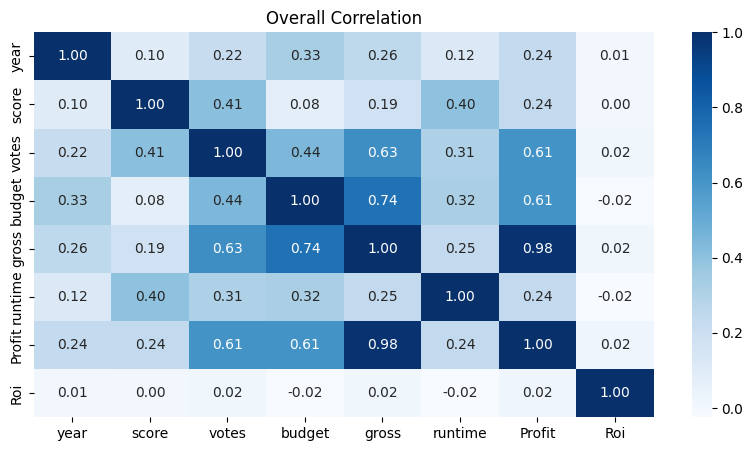

In [ ]:
plt.figure(figsize=(10,5))
sns.heatmap(df1.corr(method='pearson',numeric_only=True),annot=True,cmap='Blues',fmt='.2f')
plt.title('Overall Correlation')
plt.show()

## 📝 Simple Summary of What the Data Shows

This color-coded map pairs up our movie numbers to see how they affect each other. Based on the chart, here are the three biggest takeaways:

---

###  1. Spending Money Makes Money (Score: 0.74 ➡️ STRONG Positive Correlation)
* **What it means:** Big budgets lead to big box office sales. Because this is a **strong** relationship, it tells us that if a movie studio wants to make a massive blockbuster that pulls in hundreds of millions of dollars, they must be willing to spend a lot of money upfront to make it.

###  2. Hype and Word-of-Mouth Matter More Than Movie Reviews (Score: 0.63 ➡️ MODERATE-TO-STRONG vs. 0.19 ➡️ WEAK)
* **What it means:** Audiences do not care what elite movie critics think. The number of people talking about and voting on a movie has a **moderate-to-strong** relationship with sales. The actual score from critics has a **very weak** relationship. A movie can get terrible reviews, but if everyone on the internet is sharing memes and talking about it, it will still make a massive amount of money.

### ⏱ 3. Movie Length Doesn't Change Sales (Score: 0.25 ➡️ WEAK Positive Correlation)
* **What it means:** Because this relationship is **weak**, making a movie extra-long or keeping it short does not really change how much money it makes. Audiences will buy tickets regardless of whether a movie is 90 minutes or 3 hours long, as long as they are excited to see it.

---



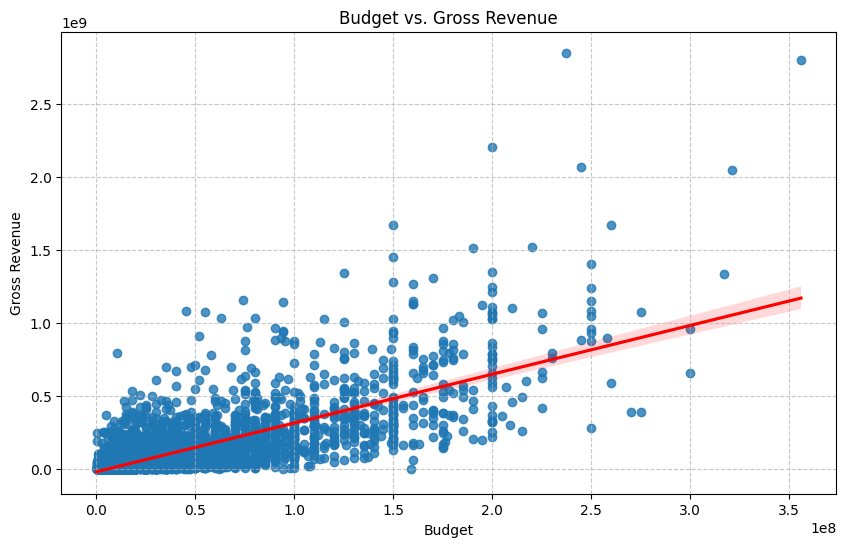

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='budget', y='gross', data=df1,line_kws={'color':'red'})
plt.title('Budget vs. Gross Revenue')
plt.xlabel('Budget')
plt.ylabel('Gross Revenue')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

The scatter plot shows a positive relationship between movie budget and gross revenue. In general, movies with larger production budgets tend to earn higher revenues, as indicated by the upward-sloping regression line. Most movies are concentrated in the lower budget and lower gross revenue range, while only a small number of movies have substantially higher budgets and revenues. The spread of data points increases as the budget increases, indicating that movies with similar budgets can generate different levels of gross revenue. Overall, the visualization suggests that budget has a positive but not perfectly predictive impact on box office performance.

## 🏁 Final Conclusion: How to Make a Successful Movie

After cleaning the data and analyzing the relationships between budgets, reviews, and earnings, here is the final playbook for running a successful movie studio:

1. **Go Big or Go Home:** The data shows a **strong positive relationship (0.74)** between budget and earnings. While spending massive money upfront is risky, it is the most reliable way to secure massive box office returns. Small budgets usually mean small returns.
2. **Focus on Hype, Not Critics:** Word-of-mouth and public engagement have a **moderate-to-strong relationship (0.63)** with gross revenue, while critical scores have a **very weak relationship (0.19)**. To make money, direct marketing budgets toward social media hype, viral trends, and getting the public talking.
3. **Don't Worry About Movie Length:** Since runtime has a **weak relationship (0.25)** with revenue, let directors make the movie as long or as short as it needs to be to tell a good story.

### 🚀 Project Complete!

**Key Metrics**

1. Top 10 Companies by Total Budget

In [ ]:
top_companies=df1.groupby('company')[['budget','gross','Profit']].sum().sort_values(by='budget',ascending=False).reset_index(drop=True).head(10)
top_companies.style.format({
    'budget': '${:,.0f}',
    'gross': '${:,.0f}',
    'Profit': '${:,.0f}'
})

,budget,gross,Profit
0,"$19,568,300,000","$56,491,421,806","$35,204,902,654"
1,"$15,989,730,001","$52,514,188,890","$35,251,375,417"
2,"$15,512,107,000","$43,008,941,346","$26,844,323,218"
3,"$13,723,450,000","$40,493,607,415","$26,298,254,691"
4,"$11,474,600,000","$40,257,053,857","$28,067,973,303"
5,"$10,404,700,000","$36,327,887,792","$25,428,950,748"
6,"$5,648,200,000","$19,883,797,684","$13,980,586,232"
7,"$4,153,700,000","$11,795,832,638","$6,510,979,494"
8,"$3,961,700,000","$11,635,441,081","$7,632,107,697"
9,"$3,548,250,000","$9,230,230,105","$5,393,760,092"


2. Top 5 Highest-ROI Movies

In [ ]:
Top_roi=df1[df1['budget']>1000000][['name','budget','gross','Profit','Roi']].sort_values(by='Roi',ascending=False).reset_index(drop=True).head(5)
Top_roi.style.format({
    'budget': '${:,.0f}',
    'gross': '${:,.0f}',
    'Profit': '${:,.0f}',
    'Roi': '{:.2%}'
})

,name,budget,gross,Profit,Roi
0,Saw,"$1,200,000","$103,911,669","$102,711,669",8559.31%
1,E.T. the Extra-Terrestrial,"$10,500,000","$792,910,554","$782,410,554",7451.53%
2,My Big Fat Greek Wedding,"$5,000,000","$368,744,044","$363,744,044",7274.88%
3,The Full Monty,"$3,500,000","$257,938,649","$254,438,649",7269.68%
4,Insidious,"$1,500,000","$99,557,032","$98,057,032",6537.14%


3. Top 5 Highest-Grossing Actors

In [ ]:
Top_actors=df1.groupby('star')[['budget','gross','Profit']].sum().sort_values(by='gross',ascending=False).reset_index(drop=True).head(5)
Top_actors.style.format({
    'budget': '${:,.0f}',
    'gross': '${:,.0f}',
    'Profit': '${:,.0f}'
})

,budget,gross,Profit
0,"$2,298,000,000","$11,859,526,234","$9,557,937,746"
1,"$2,292,000,000","$9,952,423,823","$7,607,944,903"
2,"$2,602,300,000","$9,602,552,559","$7,000,252,559"
3,"$1,123,000,000","$7,954,064,886","$5,848,268,037"
4,"$2,290,100,000","$7,947,279,234","$5,657,179,234"


4. Top 5 Highest-Grossing Directors

In [ ]:
Top_directors=df1.groupby('director')[['budget','gross','Profit']].sum().sort_values(by='gross',ascending=False).reset_index(drop=True).head(5)
Top_directors.style.format({
    'budget': '${:,.0f}',
    'gross': '${:,.0f}',
    'Profit': '${:,.0f}'
})

,budget,gross,Profit
0,"$1,891,500,000","$9,629,049,370","$7,737,549,370"
1,"$1,151,000,000","$6,844,248,984","$5,693,248,984"
2,"$1,246,000,000","$6,618,045,788","$5,372,045,788"
3,"$1,678,000,000","$6,451,692,798","$4,773,692,798"
4,"$748,900,000","$6,248,088,578","$5,499,188,578"


5. which country plus year that generated highest grossing

In [ ]:
top_country_year=df1.groupby(['country','year'])[['budget','gross','Profit']].sum().sort_values(by='gross',ascending=False).head(5)
top_country_year.style.format({
    'budget': '${:,.0f}',
    'gross': '${:,.0f}',
    'Profit': '${:,.0f}'
})

6. Highest Rated Movie

In [ ]:
highest_rated_movie=df1.sort_values(by='score',ascending=False).head(1)
highest_rated_movie[['name','budget','gross','score']].style.format({
                                                                     'budget':'${:,.0f}',
                                                                     'gross':'${:,.0f}',
                                                                     'score':'{:,.0f}'})

,name,budget,gross,score
2443,The Shawshank Redemption,"$25,000,000","$28,817,291",9


In [ ]:
df1.to_csv('cleaned_movies.csv',index=False)

In [ ]:
files.download('cleaned_movies.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>